# Image Classification Pipeline

Description:
```
- Dividir a base de dados em conjuntos separados para treino (80%), validação (10%) e teste (10%).
- Selecionar um classificador para fazer uso desses descritores; pode usar implementações do scikit-learn ou outras externas (mas nada que demande uso de GPU para classificação, a ideia é focar a maior parte do custo computacional na extração de características)
- Pets com menos de 3 fotos não entram na tarefa de classificação
```
This notebook follows the logic in `utils.py` and turns it into an exploratory workflow.

It covers:
- the class-wise split used by the project
- a visual check of the dataset
- the descriptor set used for classification
- per-descriptor and fused evaluation results

The implementation reuses the functions from `utils.py`, so the notebook stays aligned with the script version.

In [ ]:
from collections import Counter
import importlib

import matplotlib.pyplot as plt
import numpy as np

import utils as project_module
project = importlib.reload(project_module)

from utils import (
    accuracy_score,
    apply_standardization,
    build_bovw_codebook,
    combine_feature_blocks,
    extract_bundles,
    load_pet_records,
    matrix_from_bundles,
    predict_nearest_centroid,
    standardize_features,
    split_pets_by_class,
    train_nearest_centroid,
    plot_classes_distribution,
    sample_training_images,
    plot_bovw_representative_patches,
    plot_descriptor_comparison,
    plot_final_comparison,
    plot_sample_predictions
)

# Manual tuning knobs you can change and rerun.
HARALICK_LEVELS = 32
LBP_POINTS = 8
LBP_RADIUS_R1 = 1
LBP_RADIUS_R2 = 2
HOG_BINS = 8
BOVW_REGION_SIZE = 32
BOVW_CLUSTER_CANDIDATES = [
                            # 4, 
                            8, # this number of clusters was selected based on previous tests applied to the training set, yielding the best results
                            # 12, 16
                            ]
BOVW_POINTS = 8
BOVW_RADIUS = 1
GABOR_FREQUENCIES = (0.08, 0.16)
GABOR_ORIENTATIONS = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4)
GABOR_SIGMA = 4.0
GABOR_GAMMA = 0.5
HSV_BINS = 6

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load and split the dataset

The script uses a class-wise split: images are grouped by `class_name`, shuffled, and then split into train, validation, and test sets.

Classes with fewer than 3 images are skipped because they cannot support the split reliably.

In [2]:
records = load_pet_records('pets.csv')
train_records, test_records, validation_records, skipped_classes = split_pets_by_class(records)

print(f'Loaded {len(records)} images')
print(f'Train split: {len(train_records)} images')
print(f'Validation split: {len(validation_records)} images')
print(f'Test split: {len(test_records)} images')
print(f'Skipped classes: {len(skipped_classes)}')

Loaded 367 images
Train split: 268 images
Validation split: 47 images
Test split: 47 images
Skipped classes: 5


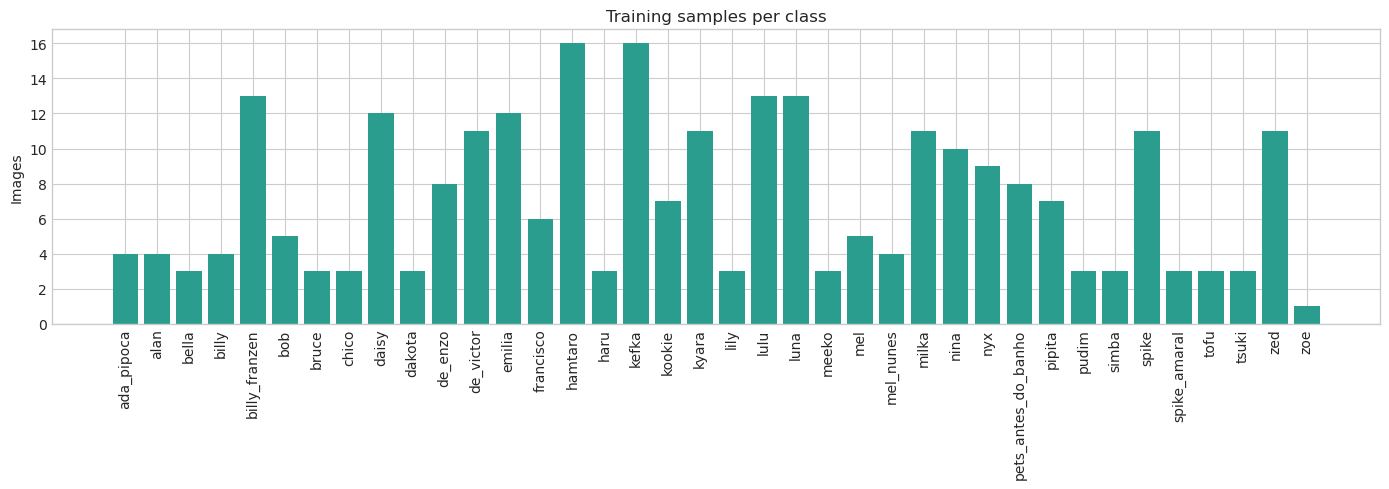

In [3]:
# Visualize how many samples each class contributes to the training split.
plot_classes_distribution(train_records)

## 2. Inspect a few images

A quick visual check is useful before feature extraction. The descriptors are sensitive to texture, color, and edge patterns, so it helps to confirm the dataset looks reasonable.

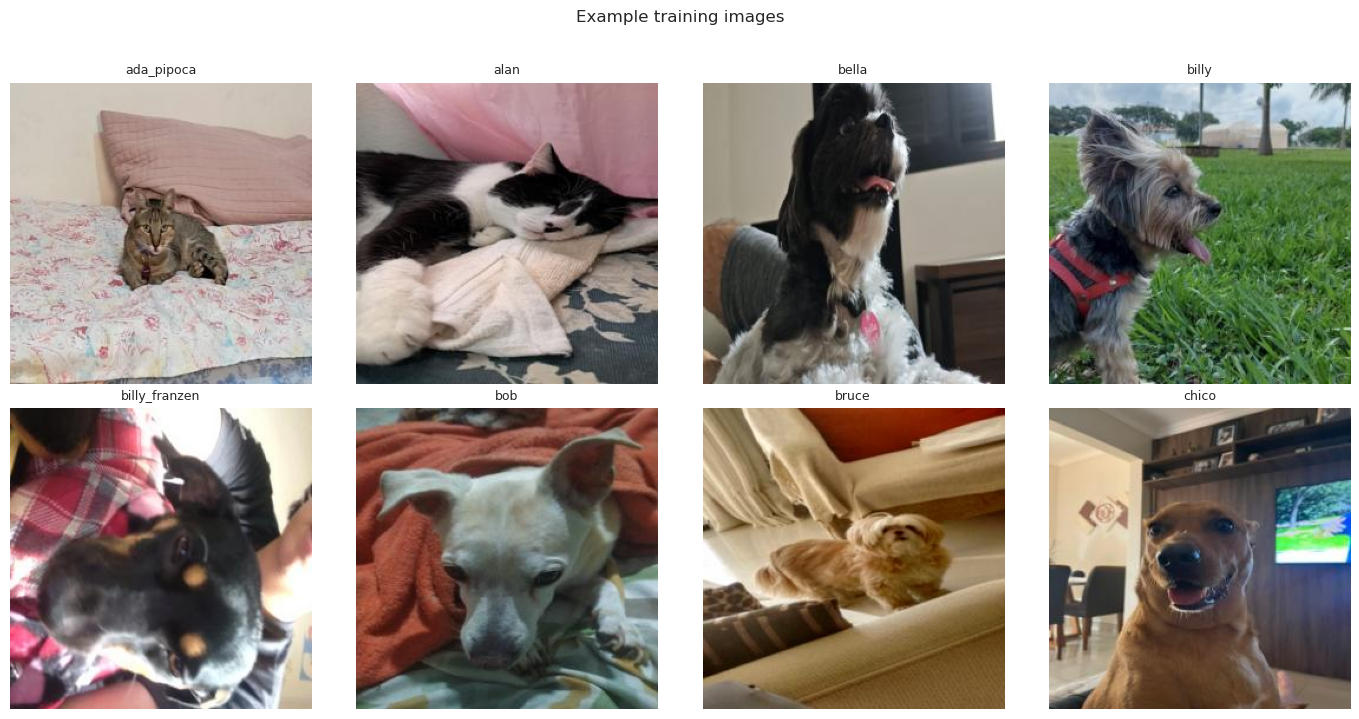

In [4]:
sample_training_images(train_records, num_samples=8)

## 3. Use a richer descriptor set

The earlier lightweight version removed BoVW, but that descriptor is useful here because it captures recurring local texture patterns at a higher level than plain histograms.

The current mix keeps the compact descriptors and adds BoVW back, plus two more strong cues:
- Haralick texture statistics
- Local Binary Patterns at two radii
- Histogram of Oriented Gradients
- Bag of Visual Words built from regional LBP patches
- Color moments in Lab space
- Gabor texture responses
- HSV color histograms

You can tune the codebook size, region size, and the texture/color parameters in the import cell above.

This gives the model both low-level and mid-level cues without changing the classifier.

In [5]:
descriptor_message = (
    'Descriptor set: Haralick, LBP r=1, LBP r=2, HOG, BoVW, color moments, Gabor, and HSV histograms.'
)
print(descriptor_message)

Descriptor set: Haralick, LBP r=1, LBP r=2, HOG, BoVW, color moments, Gabor, and HSV histograms.


## 4. Extract descriptor bundles

Each image is converted into eight feature vectors:
- Haralick texture statistics
- Local Binary Patterns with radius 1
- Local Binary Patterns with radius 2
- Histogram of Oriented Gradients
- Bag of Visual Words from regional LBP patches
- Color moments in Lab space
- Gabor texture responses
- HSV color histograms

The notebook keeps these descriptors separate first, then also evaluates a fused feature vector at the end.

In [6]:
def evaluate_descriptor_bundle(train_bundles, validation_bundles, test_bundles, train_labels, validation_labels, test_labels, descriptor_name: str):
    train_matrix = matrix_from_bundles(train_bundles, descriptor_name)
    validation_matrix = matrix_from_bundles(validation_bundles, descriptor_name)
    test_matrix = matrix_from_bundles(test_bundles, descriptor_name)

    train_scaled, mean, std = standardize_features(train_matrix)
    validation_scaled = apply_standardization(validation_matrix, mean, std)
    test_scaled = apply_standardization(test_matrix, mean, std)

    centroids = train_nearest_centroid(train_scaled, train_labels)
    validation_score = accuracy_score(validation_labels, predict_nearest_centroid(validation_scaled, centroids))
    test_score = accuracy_score(test_labels, predict_nearest_centroid(test_scaled, centroids))

    return train_scaled, validation_scaled, test_scaled, validation_score, test_score

bovw_runs = []
best_bovw = None

for cluster_count in BOVW_CLUSTER_CANDIDATES:
    bovw_codebook = build_bovw_codebook(
        train_records,
        region_size=BOVW_REGION_SIZE,
        clusters=cluster_count,
        points=BOVW_POINTS,
        radius=BOVW_RADIUS,
    )
    print(f'BoVW codebook size ({cluster_count} clusters): {len(bovw_codebook)}')

    train_labels, train_bundles = extract_bundles(
        train_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    validation_labels, validation_bundles = extract_bundles(
        validation_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    test_labels, test_bundles = extract_bundles(
        test_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )

    train_scaled, validation_scaled, test_scaled, validation_score, test_score = evaluate_descriptor_bundle(train_bundles, validation_bundles, test_bundles, train_labels, validation_labels, test_labels,'bovw')

    bovw_runs.append({
        'clusters': cluster_count,
        'codebook': bovw_codebook,
        'train_labels': train_labels,
        'train_bundles': train_bundles,
        'validation_labels': validation_labels,
        'validation_bundles': validation_bundles,
        'test_labels': test_labels,
        'test_bundles': test_bundles,
        'validation_score': validation_score,
        'test_score': test_score,
    })

    if best_bovw is None or validation_score > best_bovw['validation_score']:
        best_bovw = bovw_runs[-1]

assert best_bovw is not None
print(f"Best BoVW clusters by validation: {best_bovw['clusters']}")
print(f"Best BoVW validation accuracy: {best_bovw['validation_score']:.3f}")
print(f"Best BoVW test accuracy: {best_bovw['test_score']:.3f}")

bovw_codebook = best_bovw['codebook']
train_labels = best_bovw['train_labels']
train_bundles = best_bovw['train_bundles']
validation_labels = best_bovw['validation_labels']
validation_bundles = best_bovw['validation_bundles']
test_labels = best_bovw['test_labels']
test_bundles = best_bovw['test_bundles']

descriptor_names = ['haralick', 'lbp_r1', 'lbp_r2', 'hog', 'bovw', 'color_moments', 'gabor', 'hsv_histogram']
descriptor_labels = {
    'haralick': 'Haralick',
    'lbp_r1': 'LBP r=1',
    'lbp_r2': 'LBP r=2',
    'hog': 'HOG',
    'bovw': 'BoVW',
    'color_moments': 'Color moments',
    'gabor': 'Gabor',
    'hsv_histogram': 'HSV hist',
}

results = {}
scaled_blocks = {'train': [], 'validation': [], 'test': []}

for descriptor_name in descriptor_names:
    train_scaled, validation_scaled, test_scaled, validation_score, test_score = evaluate_descriptor_bundle(train_bundles, validation_bundles, test_bundles, train_labels, validation_labels, test_labels, descriptor_name)
    results[descriptor_labels[descriptor_name]] = {
        'validation': validation_score,
        'test': test_score,
    }
    scaled_blocks['train'].append(train_scaled)
    scaled_blocks['validation'].append(validation_scaled)
    scaled_blocks['test'].append(test_scaled)

results

BoVW codebook size (8 clusters): 8
Best BoVW clusters by validation: 8
Best BoVW validation accuracy: 0.021
Best BoVW test accuracy: 0.106


{'Haralick': {'validation': 0.0425531914893617, 'test': 0.06382978723404255},
 'LBP r=1': {'validation': 0.14893617021276595, 'test': 0.1276595744680851},
 'LBP r=2': {'validation': 0.0425531914893617, 'test': 0.10638297872340426},
 'HOG': {'validation': 0.0425531914893617, 'test': 0.1702127659574468},
 'BoVW': {'validation': 0.02127659574468085, 'test': 0.10638297872340426},
 'Color moments': {'validation': 0.10638297872340426,
  'test': 0.1276595744680851},
 'Gabor': {'validation': 0.0851063829787234, 'test': 0.2127659574468085},
 'HSV hist': {'validation': 0.14893617021276595, 'test': 0.1276595744680851}}

## 4. Visualize BoVW words

The virtual words are the codebook centroids learned from regional LBP patches.
To make them interpretable, we can show the most similar image patch found in the training set for each centroid.

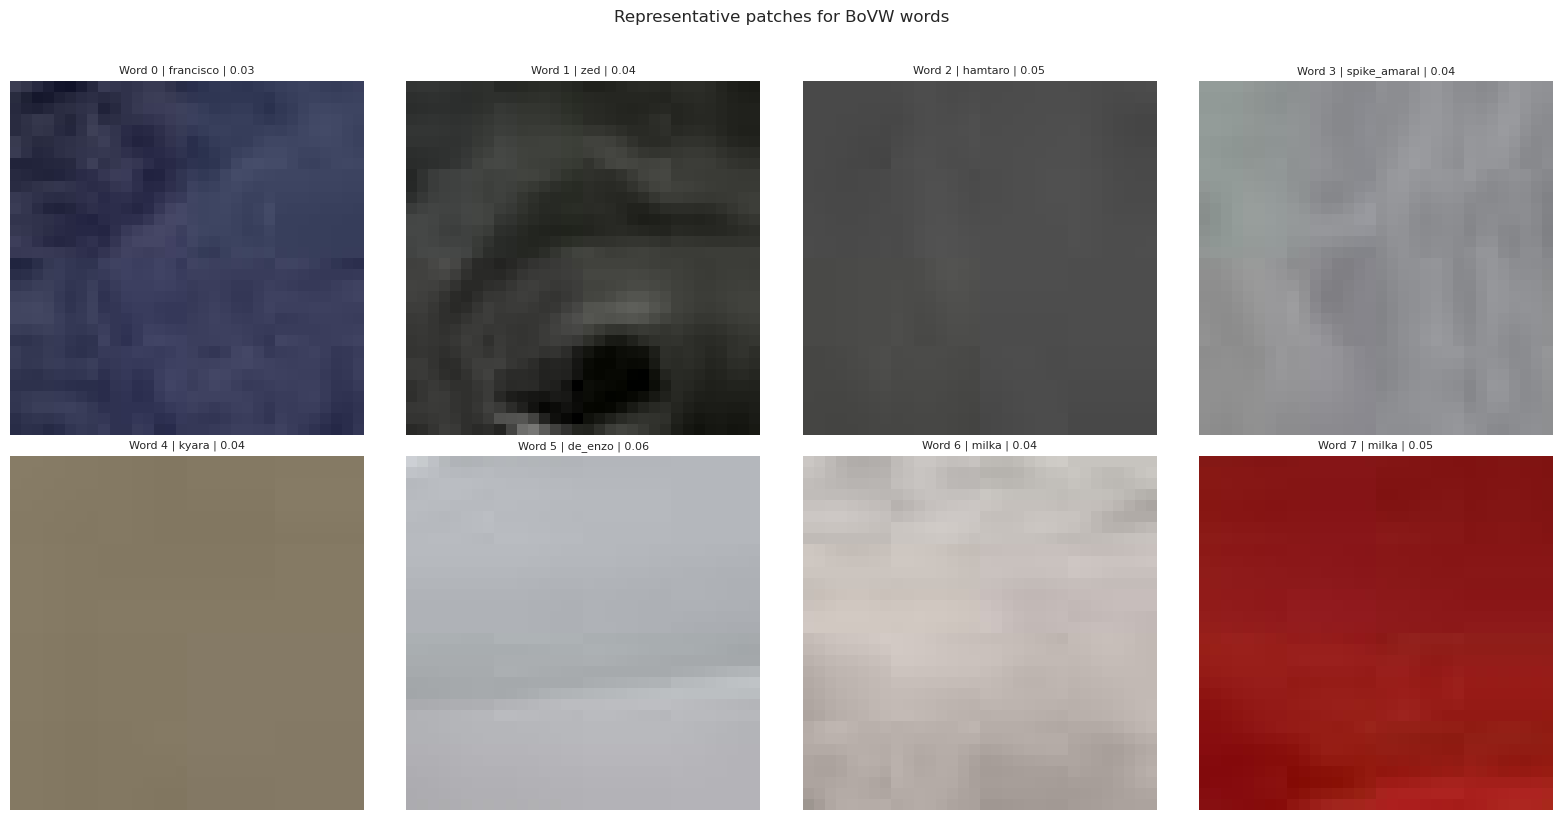

In [7]:
plot_bovw_representative_patches(bovw_codebook, train_records, region_size=BOVW_REGION_SIZE, points=BOVW_POINTS, radius=BOVW_RADIUS)

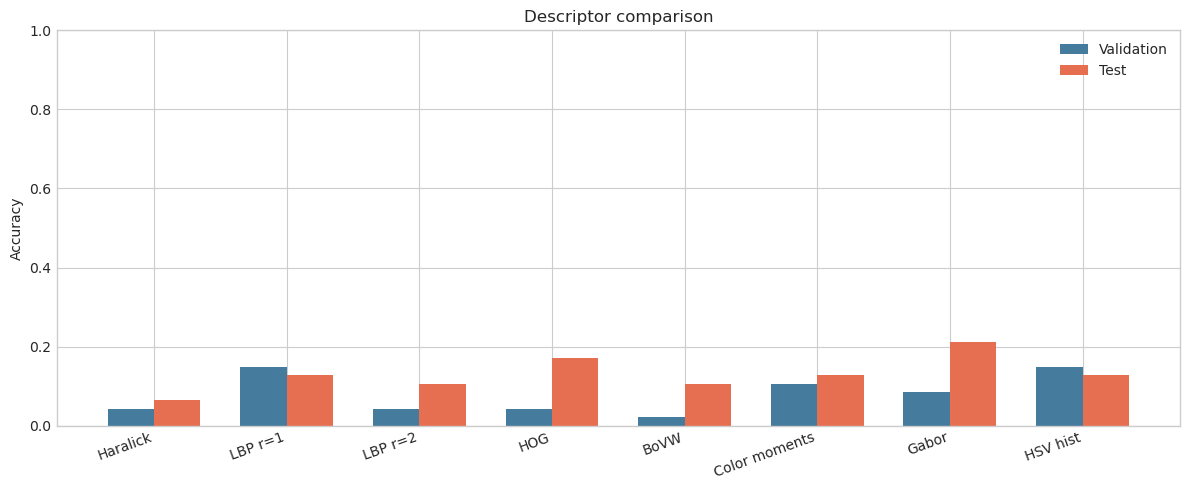

In [8]:
labels = list(results)
validation_scores = [results[label]['validation'] for label in labels]
test_scores = [results[label]['test'] for label in labels]

plot_descriptor_comparison(labels, validation_scores, test_scores)

## 5. Fuse the descriptors

The final step concatenates the standardized descriptor blocks and evaluates the same nearest-centroid classifier on the combined representation. This shows whether the descriptors complement each other.

In [9]:
descriptor_validation_scores = np.array([results[label]['validation'] for label in labels], dtype=np.float64)
weight_vector = descriptor_validation_scores / descriptor_validation_scores.sum() if descriptor_validation_scores.sum() > 0 else np.full(len(labels), 1.0 / len(labels))

weights = dict(zip(labels, weight_vector))
print('Descriptor weights based on validation accuracy:')
for name, weight in weights.items():
    print(f'{name}: {weight:.3f}')

weighted_train = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['train'], weight_vector)])
weighted_validation = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['validation'], weight_vector)])
weighted_test = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['test'], weight_vector)])

weighted_centroids = train_nearest_centroid(weighted_train, train_labels)
weighted_validation_score = accuracy_score(validation_labels, predict_nearest_centroid(weighted_validation, weighted_centroids))
weighted_test_score = accuracy_score(test_labels, predict_nearest_centroid(weighted_test, weighted_centroids))

print(f'Weighted validation accuracy: {weighted_validation_score:.3f}')
print(f'Weighted test accuracy: {weighted_test_score:.3f}')

Descriptor weights based on validation accuracy:
Haralick: 0.067
LBP r=1: 0.233
LBP r=2: 0.067
HOG: 0.067
BoVW: 0.033
Color moments: 0.167
Gabor: 0.133
HSV hist: 0.233
Weighted validation accuracy: 0.170
Weighted test accuracy: 0.149


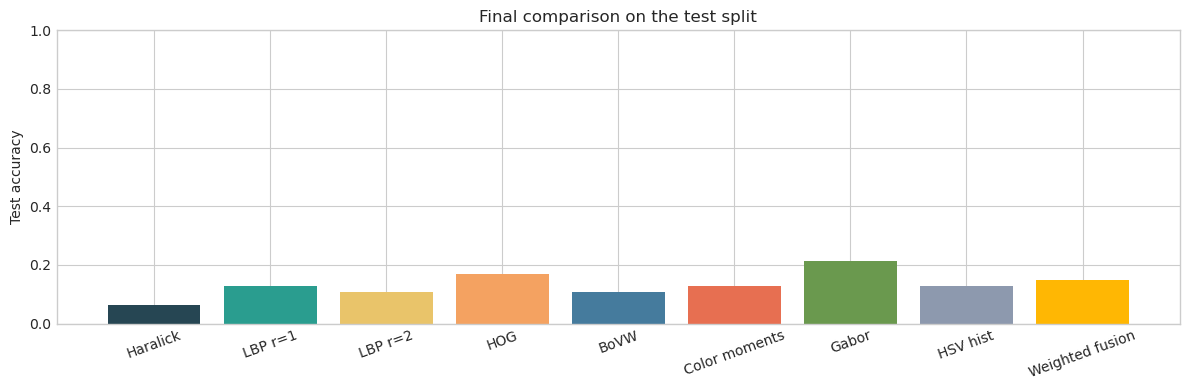

In [10]:
# Visual summary of the pipeline performance.
summary_labels = labels + ['Weighted fusion']
summary_scores = test_scores + [weighted_test_score]

plot_final_comparison(summary_labels, summary_scores)

## Notes

- The notebook mirrors the pipeline in `project.py`.
- Haralick, both LBP scales, HOG, and BoVW are based on the methods in `descritores_02.html`.
- Color moments, Gabor, and HSV histograms add complementary low-cost cues without changing the classifier.
- The simple nearest-centroid classifier keeps the notebook self-contained and easy to inspect.
- The final fusion is weighted by validation accuracy, so stronger descriptors contribute more.
- The BoVW codebook is searched over several cluster counts and the best one is kept automatically.

## 6. Rerun on well-sampled classes

To check whether the previous results were hurt by class imbalance, rerun the whole pipeline on only the classes that had more than 10 training samples in the original split.

In [11]:
selected_classes = [class_name for class_name, count in Counter(record.class_name for record in train_records).items() if count > 10]
subset_records = [record for record in records if record.class_name in selected_classes]

print(f'Selected classes: {len(selected_classes)}')
print(', '.join(sorted(selected_classes)))
print(f'Subset images: {len(subset_records)}')

subset_train_records, subset_test_records, subset_validation_records, subset_skipped = split_pets_by_class(subset_records)
print(f'Subset train: {len(subset_train_records)}')
print(f'Subset validation: {len(subset_validation_records)}')
print(f'Subset test: {len(subset_test_records)}')

subset_bovw_runs = []
subset_best_bovw = None

for cluster_count in BOVW_CLUSTER_CANDIDATES:
    subset_codebook = build_bovw_codebook(
        subset_train_records,
        region_size=BOVW_REGION_SIZE,
        clusters=cluster_count,
        points=BOVW_POINTS,
        radius=BOVW_RADIUS,
    )
    print(f'Subset BoVW codebook size ({cluster_count} clusters): {len(subset_codebook)}')

    subset_train_labels, subset_train_bundles = extract_bundles(
        subset_train_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    subset_validation_labels, subset_validation_bundles = extract_bundles(
        subset_validation_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    subset_test_labels, subset_test_bundles = extract_bundles(
        subset_test_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )

    subset_train_scaled, subset_validation_scaled, subset_test_scaled, subset_validation_score, subset_test_score = \
        evaluate_descriptor_bundle(subset_train_bundles, subset_validation_bundles, subset_test_bundles, subset_train_labels, subset_validation_labels, subset_test_labels,'bovw')

    subset_bovw_runs.append({
        'clusters': cluster_count,
        'codebook': subset_codebook,
        'train_labels': subset_train_labels,
        'train_bundles': subset_train_bundles,
        'validation_labels': subset_validation_labels,
        'validation_bundles': subset_validation_bundles,
        'test_labels': subset_test_labels,
        'test_bundles': subset_test_bundles,
        'validation_score': subset_validation_score,
        'test_score': subset_test_score,
    })

    if subset_best_bovw is None or subset_validation_score > subset_best_bovw['validation_score']:
        subset_best_bovw = subset_bovw_runs[-1]

assert subset_best_bovw is not None
print(f"Subset best BoVW clusters by validation: {subset_best_bovw['clusters']}")
print(f"Subset best BoVW validation accuracy: {subset_best_bovw['validation_score']:.3f}")
print(f"Subset best BoVW test accuracy: {subset_best_bovw['test_score']:.3f}")

subset_bovw_codebook = subset_best_bovw['codebook']
subset_train_labels = subset_best_bovw['train_labels']
subset_train_bundles = subset_best_bovw['train_bundles']
subset_validation_labels = subset_best_bovw['validation_labels']
subset_validation_bundles = subset_best_bovw['validation_bundles']
subset_test_labels = subset_best_bovw['test_labels']
subset_test_bundles = subset_best_bovw['test_bundles']

subset_descriptor_names = descriptor_names
subset_results = {}
subset_scaled_blocks = {'train': [], 'validation': [], 'test': []}

for subset_descriptor_name in subset_descriptor_names:

    subset_train_scaled, subset_validation_scaled, subset_test_scaled, subset_validation_score, subset_test_score = \
        evaluate_descriptor_bundle(subset_train_bundles, subset_validation_bundles, subset_test_bundles, subset_train_labels, subset_validation_labels, subset_test_labels, subset_descriptor_name)

    subset_results[descriptor_labels[subset_descriptor_name]] = {
        'test': subset_test_score,
        'validation': subset_validation_score,
    }
    subset_scaled_blocks['train'].append(subset_train_scaled)
    subset_scaled_blocks['validation'].append(subset_validation_scaled)
    subset_scaled_blocks['test'].append(subset_test_scaled)

subset_validation_scores = np.array([subset_results[label]['validation'] for label in list(subset_results)], dtype=np.float64)
subset_weight_vector = subset_validation_scores / subset_validation_scores.sum() if subset_validation_scores.sum() > 0 else np.full(len(subset_results), 1.0 / len(subset_results))

subset_weighted_train = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['train'], subset_weight_vector)])
subset_weighted_validation = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['validation'], subset_weight_vector)])
subset_weighted_test = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['test'], subset_weight_vector)])

subset_weighted_centroids = train_nearest_centroid(subset_weighted_train, subset_train_labels)
subset_weighted_validation_score = accuracy_score(subset_validation_labels, predict_nearest_centroid(subset_weighted_validation, subset_weighted_centroids))
subset_weighted_test_score = accuracy_score(subset_test_labels, predict_nearest_centroid(subset_weighted_test, subset_weighted_centroids))

print('Subset descriptor weights:')
for name, weight in zip(subset_results, subset_weight_vector):
    print(f'{name}: {weight:.3f}')

print(f'Subset weighted validation accuracy: {subset_weighted_validation_score:.3f}')
print(f'Subset weighted test accuracy: {subset_weighted_test_score:.3f}')

Selected classes: 12
billy_franzen, daisy, de_victor, emilia, hamtaro, kefka, kyara, lulu, luna, milka, spike, zed
Subset images: 192
Subset train: 150
Subset validation: 21
Subset test: 21
Subset BoVW codebook size (8 clusters): 8
Subset best BoVW clusters by validation: 8
Subset best BoVW validation accuracy: 0.190
Subset best BoVW test accuracy: 0.190
Subset descriptor weights:
Haralick: 0.021
LBP r=1: 0.128
LBP r=2: 0.128
HOG: 0.106
BoVW: 0.085
Color moments: 0.213
Gabor: 0.149
HSV hist: 0.170
Subset weighted validation accuracy: 0.381
Subset weighted test accuracy: 0.190


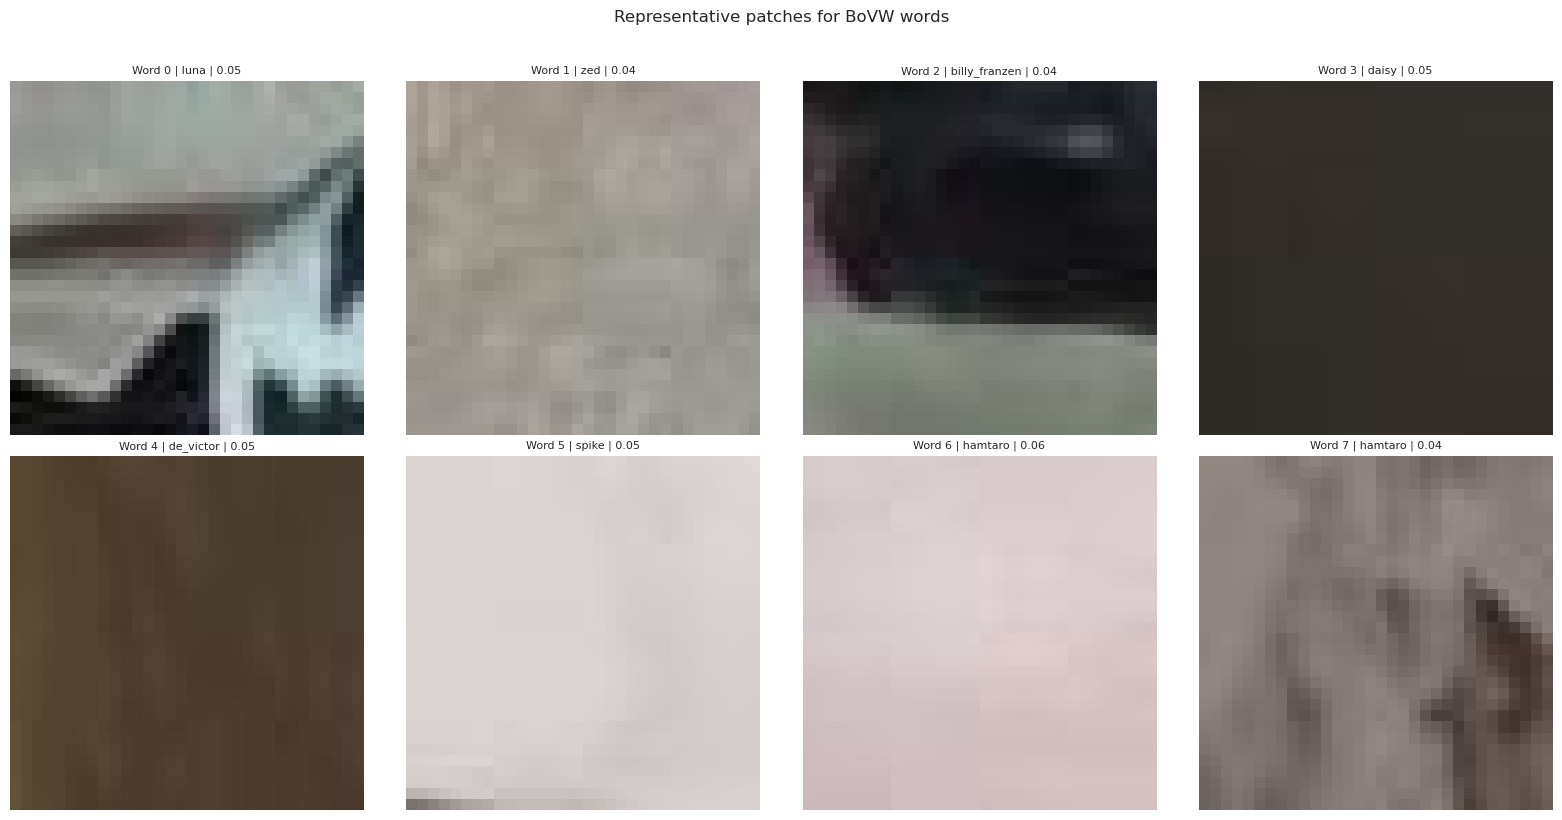

In [12]:
plot_bovw_representative_patches(subset_bovw_codebook, subset_train_records, region_size=BOVW_REGION_SIZE, points=BOVW_POINTS, radius=BOVW_RADIUS)

Here, the bag of words already seems to emphasize some characteristics that make a little more sense, such as parts that appear to be animal fur or even Kyara's paw, for example.

## 7. Visualize the well-sampled subset

The rerun on classes with more than 10 training samples should be read the same way as the full pipeline: first compare the descriptors, then check whether the weighted fusion improves the final result.

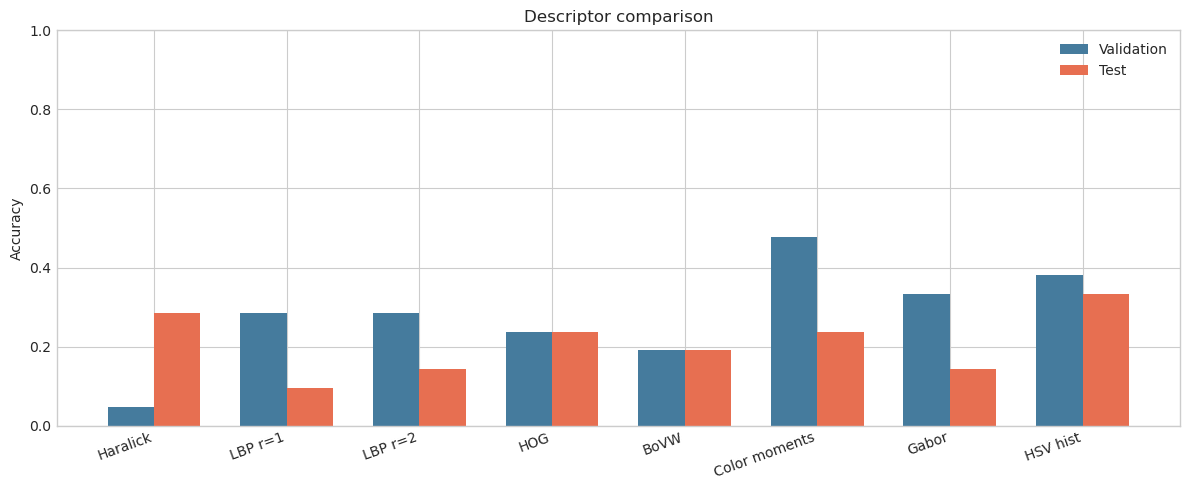

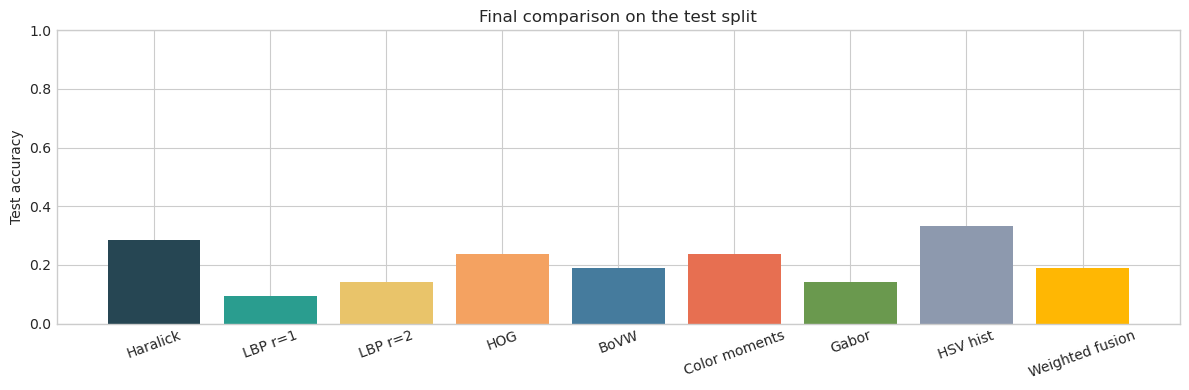

In [13]:
subset_labels = list(subset_results)
subset_validation_scores = [subset_results[label]['validation'] for label in subset_labels]
subset_test_scores = [subset_results[label]['test'] for label in subset_labels]

plot_descriptor_comparison(subset_labels, subset_validation_scores, subset_test_scores)

subset_summary_labels = subset_labels + ['Weighted fusion']
subset_summary_scores = subset_test_scores + [subset_weighted_test_score]

plot_final_comparison(subset_summary_labels, subset_summary_scores)

### Prediction tests

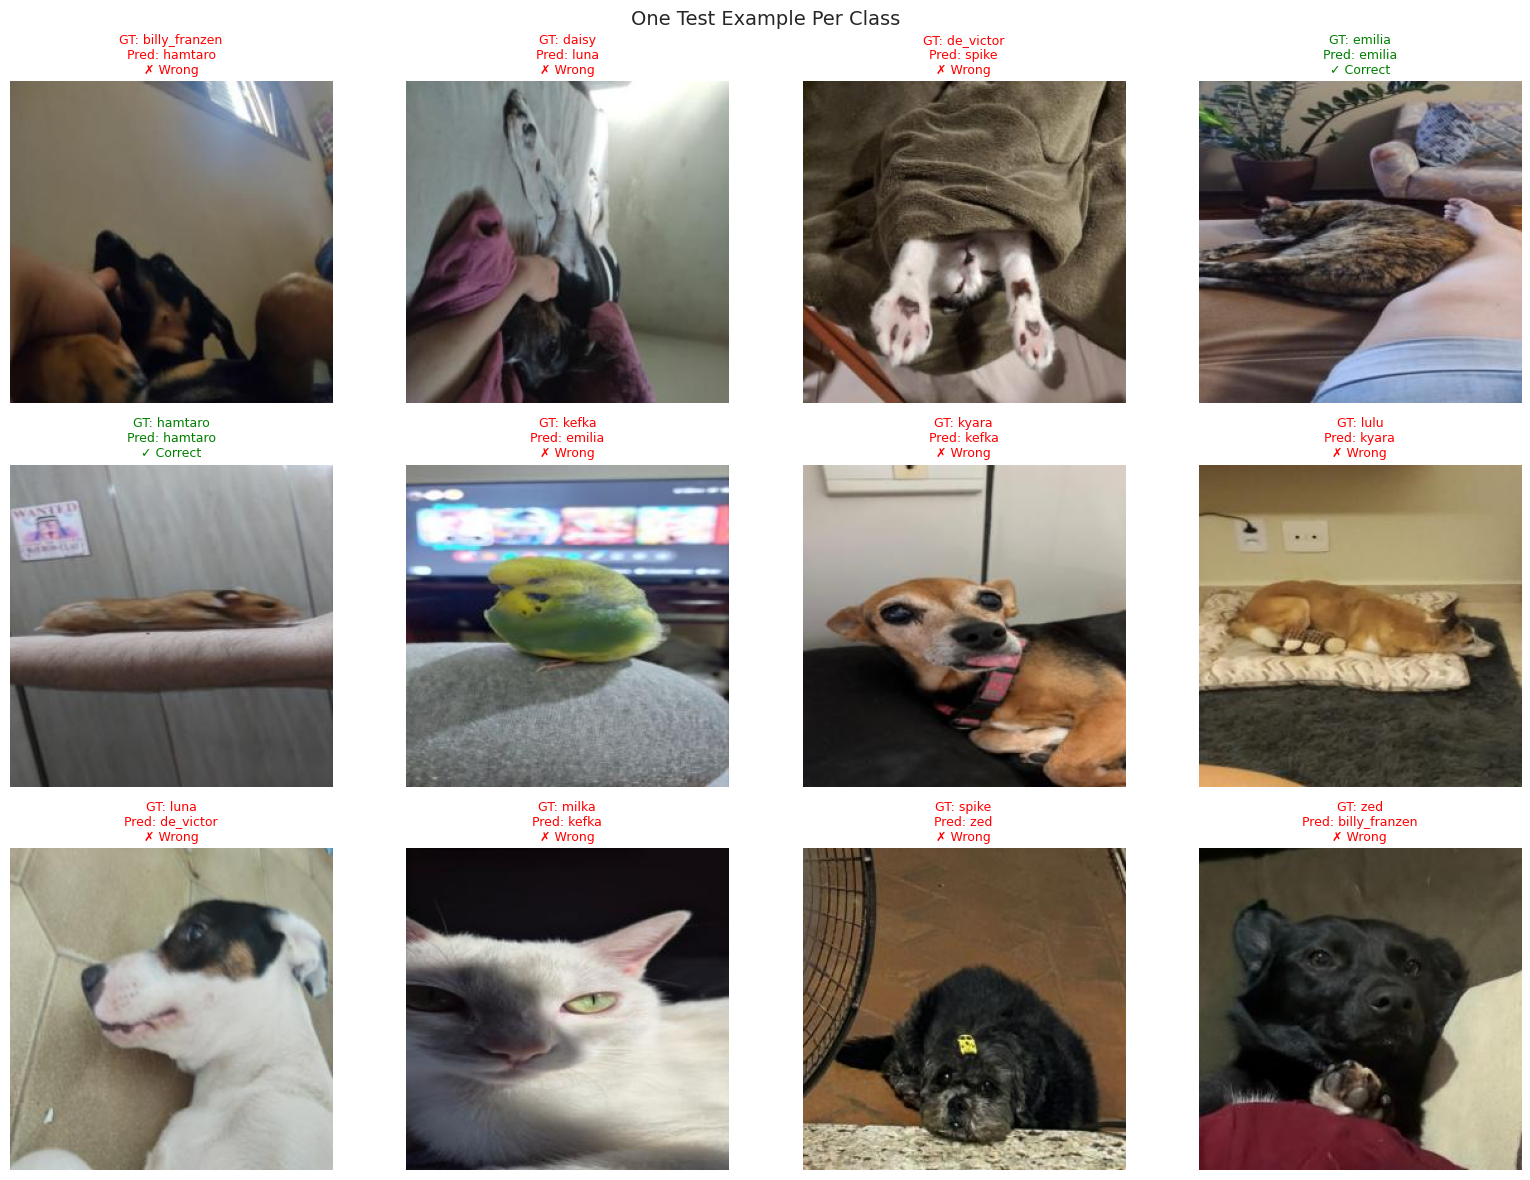

Test Accuracy: 0.190


In [15]:
subset_test_predictions = predict_nearest_centroid(
    subset_weighted_test,
    subset_weighted_centroids
)

plot_sample_predictions(subset_test_records, subset_test_labels, subset_test_predictions)